In [7]:
import numpy as np
from matplotlib import pyplot as plt
from sktime.forecasting.base import ForecastingHorizon
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.split import temporal_train_test_split
from sktime.performance_metrics.forecasting import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, mean_absolute_scaled_error

import pandas as pd

from typing import Dict, Iterable
import pickle

from load_data import get_production_data, project_root

prod_df: pd.DataFrame = get_production_data().set_index("dt")

prod_df

,actual,xgboost
dt,,
2025-08-13 00:25:31.218000+00:00,1.67,1.40
2025-08-13 01:00:30.639000+00:00,1.76,1.54
2025-08-13 01:35:53.186000+00:00,1.71,1.46
2025-08-13 02:09:42.947000+00:00,1.82,1.52
2025-08-13 02:46:50.045000+00:00,1.62,1.39
...,...,...
2025-11-03 18:44:26.173000+00:00,1.88,1.34
2025-11-03 19:17:15.433000+00:00,2.25,1.34
2025-11-03 19:50:34.061000+00:00,2.18,1.57


In [8]:
train_df: pd.DataFrame
test_df: pd.DataFrame
train_df, test_df = temporal_train_test_split(prod_df, test_size=0.2)

y_train: pd.Series
y_test: pd.Series
y_train, y_test = train_df["actual"], test_df["actual"]

In [9]:
from autots import AutoTS

def to_regular_dt_grid(df: pd.DataFrame, freq: str, interpolation_actions: Dict[str, str]) -> pd.DataFrame:
    reg_grid = df.resample(freq).ffill().index
    union_df = df.reindex(df.index.union(reg_grid))
    for column, strategy in interpolation_actions.items():
        union_df[column] = union_df[column].interpolate(method=strategy)
    return union_df.reindex(reg_grid).dropna()

reg_prod_df = to_regular_dt_grid(prod_df[["actual"]], freq="30min", interpolation_actions={"actual": "time"})
last_y_train_dt = y_train.index[-1]
reg_train_df: pd.DataFrame = reg_prod_df.loc[:last_y_train_dt]
reg_test_df: pd.DataFrame = reg_prod_df.loc[last_y_train_dt:]

def autots_fit_or_load(variant_names: Iterable[str]) -> Dict[str, AutoTS]:
    def pickle_path(variant_name: str) -> str:
        return "autots_model_{}.pkl".format(variant_name)

    def load_model(variant_name: str) -> AutoTS | None:
        try:
            with open(pickle_path(variant_name), "rb") as f:
                return pickle.load(f)
        except FileNotFoundError:
                return None

    def train_and_save_model(variant_name: str) -> AutoTS:
        autots = AutoTS(
            forecast_length=len(reg_test_df),
            frequency='infer',
            ensemble='super',
            max_generations=8,
            num_validations=2,
            n_jobs=6,
        )
        autots.fit(reg_train_df, result_file='autots_results_{}_test.csv'.format(variant_name))
        with open(pickle_path(variant_name), 'wb') as f:
            pickle.dump(autots, f)
        return autots
    return { variant_name: load_model(variant_name) or train_and_save_model(variant_name) for variant_name in variant_names }

autots_models = autots_fit_or_load(("univariate", "super"))

In [10]:
autots_preds = { "AutoTS-{}-{}".format(variant_name, model.best_model["Model"].iloc[0]): model.predict().forecast["actual"]
                 for variant_name, model in autots_models.items() }

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='actual'>)

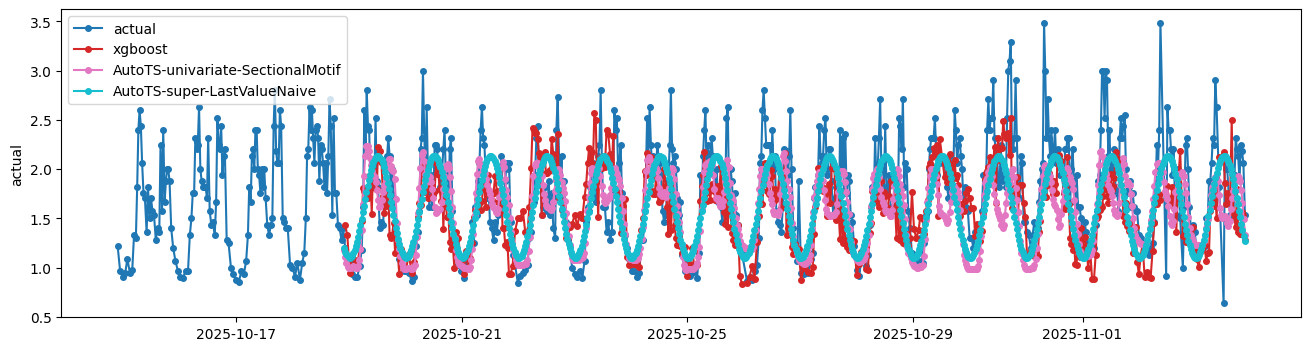

In [11]:
from sktime.utils.plotting import plot_series

train_plot_cutoff = last_y_train_dt - pd.Timedelta(days=4)

xgboost_pred = prod_df["xgboost"][last_y_train_dt:].iloc[1:]

actual_for_plot_df = prod_df[train_plot_cutoff:]["actual"]
plot_labels = ["actual", "xgboost"] + list(autots_preds.keys())
plot_colors = plt.cm.tab10(np.linspace(0, 1, len(plot_labels)))
series_to_plot = [actual_for_plot_df, xgboost_pred] + list(autots_preds.values())
plot_series(*series_to_plot, labels=plot_labels, colors=plot_colors)

In [12]:
forecasting_metrics = {'MAE': mean_absolute_error, 'MAPE': mean_absolute_percentage_error, 'MSE': mean_squared_error, 'MASE': mean_absolute_scaled_error}

def back_to_test_grid(series: pd.Series, interpolation_action: str) -> pd.DataFrame:
    union_ser = series.reindex(series.index.union(test_df.index))
    union_ser.interpolate(method=interpolation_action, inplace=True)
    return union_ser.reindex(y_test.index)

reindexed_autots_preds = { vn: back_to_test_grid(predictions, interpolation_action='time') for vn, predictions in autots_preds.items() }
predictions = {'xgBoost': xgboost_pred} | reindexed_autots_preds


def metrics_for_predictions(predictions: pd.Series) -> Dict[str, np.float64]:
    return {metric_name: metric(y_pred=predictions, y_true=y_test, y_train=y_train) for metric_name, metric in forecasting_metrics.items()}

metrics_data = {model_name: metrics_for_predictions(predictions) for model_name, predictions in predictions.items()}
pd.DataFrame(data=metrics_data).T.sort_values(by=['MAE', 'MSE'])

,MAE,MAPE,MSE,MASE
AutoTS-univariate-SectionalMotif,0.292300,0.153763,0.149295,1.009476
AutoTS-super-LastValueNaive,0.341764,0.187485,0.196786,1.180301
xgBoost,0.374702,0.203393,0.232713,1.294054
